In [ ]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
from tqdm import tqdm
from shutil import copy, rmtree
import pandas as pd
from datasets import load_dataset
from numpy.random import choice
import random
from PIL import Image
import numpy as np

sys.path.append("..")
from src import *

# Prepare dataset for ControlNet training

##### ℹ️ This notebook requires the triplets `uv`, `caption` and `diffuse` for each dataset considered

In this notebook we move all the generated triplets to a single folder, compliant with `ImageFolder` dataset. See more at [Create an image dataset](https://huggingface.co/docs/datasets/image_dataset#imagefolder)

In [35]:
MAX_DATASET_SIZE = None  # 1_000
TEST_SET_RATIO = 0.01  # diffusers train script doesn't use a test set
OUTPUT_PATH = Path("dataset").resolve()
VALIDATION_UIDS = [
    "ffebd77d0373462eb7c6d2d4941eb39c",
    "0a2ad73285bc44d7a4362f54f5de3cc4",
    "0adf456c59094a3da23329a6d27cb239",
    "0cde463ba5d64acd979ab2d4e31fded0",
    "3b15c410f87f42daa7e8cb5b5f74e3f1",
]

In [3]:
datasets: list[Dataset3D] = [ObjaverseDataset3D()]

## Mask diffuse on UV domain

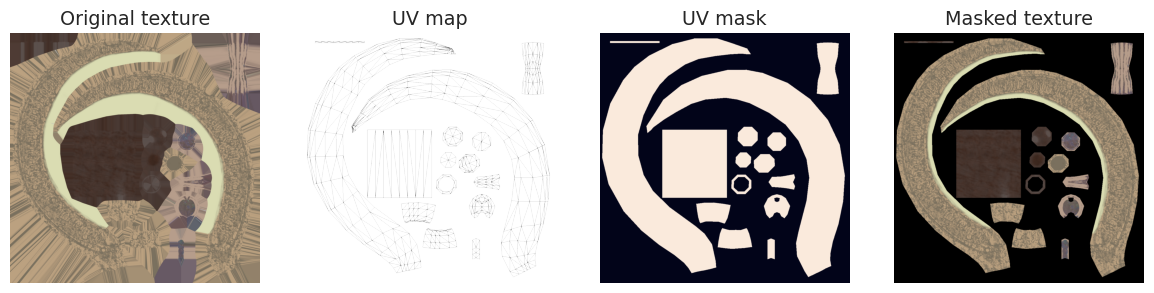

In [6]:
def mask_image(image: Image.Image, mask: np.ndarray) -> Image.Image:
    image = image.convert("RGB")
    mask_pil = Image.fromarray(mask.astype(np.uint8) * 255)
    mask_pil = mask_pil.resize(image.size[:2], resample=Image.NEAREST)
    mask = np.array(mask_pil)
    mask = np.stack([mask] * 3, axis=-1)
    return Image.fromarray(np.where(mask, image, 0))


masks = [x.stem for x in (datasets[0].DATASET_DIR / "mask").glob("*")]
uid = random.choice(masks)
mask = np.unpackbits(np.load(datasets[0].DATASET_DIR / "mask" / f"{uid}.npy")).reshape(1024, 1024)
diffuse = Image.open(datasets[0].DATASET_DIR / "diffuse" / f"{uid}.png")
uv = Image.open(datasets[0].DATASET_DIR / "uv" / f"{uid}.png")
imshow(
    {
        "Original texture": diffuse,
        "UV map": uv,
        "UV mask": mask,
        "Masked texture": mask_image(diffuse, mask),
    }
)

## Preview generated trainset
Run [`preparate_dataset.py`](preparate_dataset.py) before continuing.

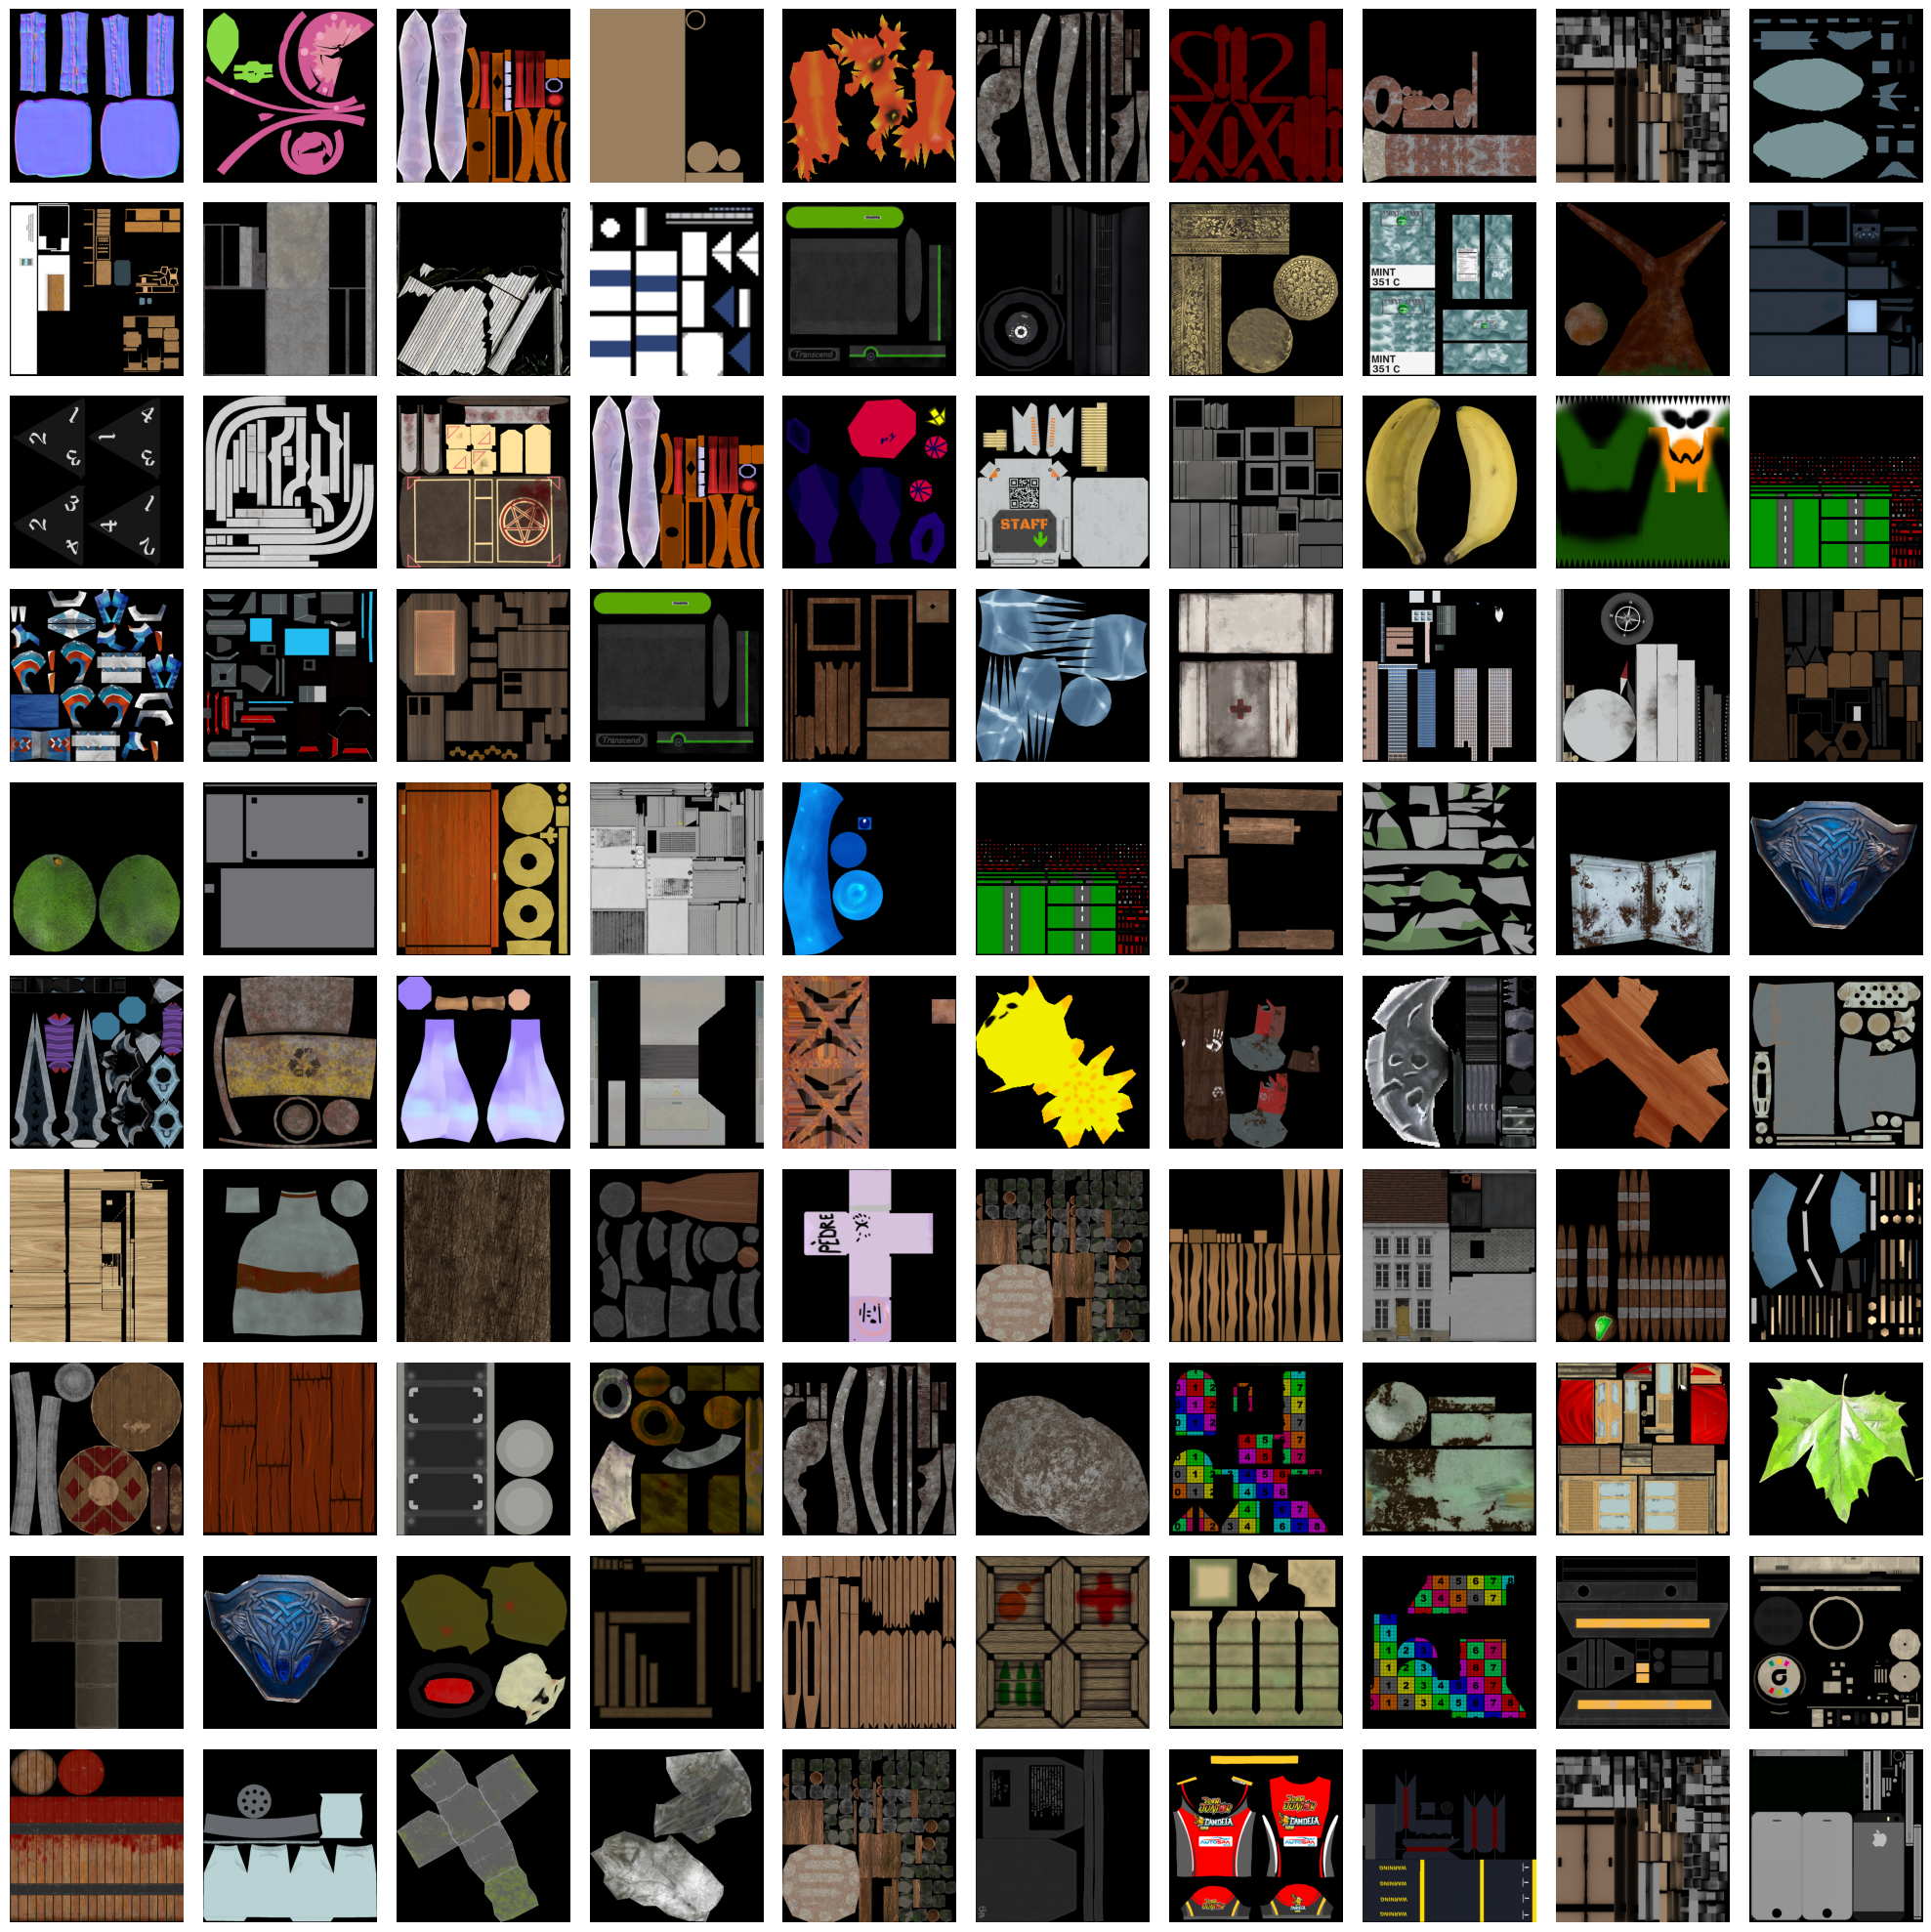

In [21]:
train_files = [x.name for x in (OUTPUT_PATH / "train" / "diffuse").glob("*")]
files = random.choices(train_files, k=100)
imshow([str(OUTPUT_PATH / "train" / "diffuse" / x) for x in files], size=2)

In [25]:
size = sum(f.stat().st_size for f in (OUTPUT_PATH).glob("**/*") if f.is_file())
cprint("Dataset size:", size // 1024**2, "green:MiB")

Dataset size: 4,791 MiB


## Create testset sampling from trainset

In [ ]:
trainset_path = Path("dataset/train")
testset_path = Path("dataset/test")
trainset = pd.read_json(
    trainset_path / "metadata.jsonl",
    orient="records",
    lines=True,
)
testset = trainset.sample(100)
testset.to_json(
    testset_path / "metadata.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
    index=False,
)
trainset.drop(testset.index, inplace=True)
trainset.to_json(
    trainset_path / "metadata.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
    index=False,
)
for _, row in testset.iterrows():
    # Move files
    diffuse: Path = trainset_path / row["diffuse_file_name"]
    diffuse.rename(testset_path / row["diffuse_file_name"])
    uv: Path = trainset_path / row["uv_file_name"]
    uv.rename(testset_path / row["uv_file_name"])

## Load dataset and preview validation set

Generating train split: 1963 examples [00:00, 64314.04 examples/s]
Generating validation split: 4 examples [00:00, 2463.61 examples/s]
Generating test split: 98 examples [00:00, 35748.98 examples/s]


Dataset has 1963 train samples, 98 test samples, 4 validation samples,


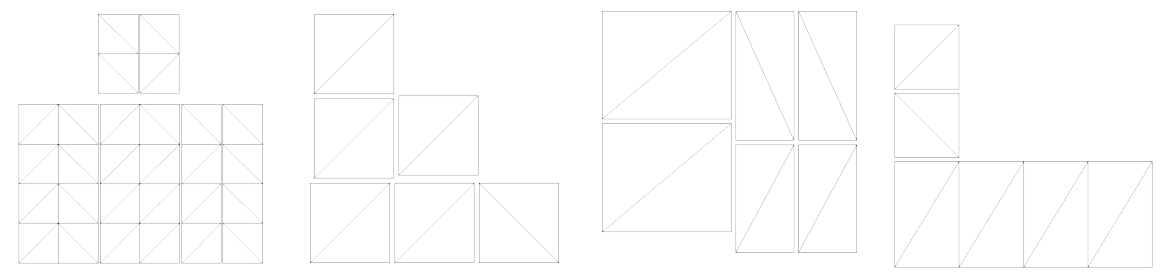

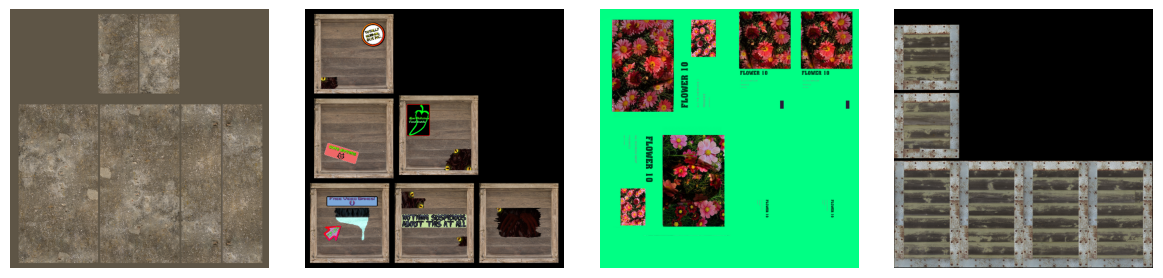

- a rectangular box with a rough, weathered surface, showing signs of age and exposure to the elements. the color is a muted, earthy tone with a mix of grays and browns, suggesting a metallic or stone material.
- a rustic wooden box with a weathered finish, featuring a dark brown hue and natural wood grain patterns. the box has a rectangular shape with a flat top and a small, round, black handle on the front. a red sticker with the text "cute burros" is affixed to
- a vibrant, teal-colored box with a floral pattern on the front and a smaller image on the side, showcasing a variety of flowers with detailed petals and centers.
- a rectangular metal plate with a rusted surface, featuring vertical stripes and a series of rivets along the edges.


In [56]:
# ~1 min
dataset = load_dataset(str(OUTPUT_PATH))
cprint(
    "Dataset has",
    f"blue:{len(dataset['train'])} train samples,",
    f"green:{len(dataset['test'])} test samples,",
    f"yellow:{len(dataset['validation'])} validation samples,",
)
imshow(dataset["validation"]["uv"])
imshow(dataset["validation"]["diffuse"])
cprint("green:- " + "\n- ".join(dataset["validation"]["caption"]))